In [1]:
import numpy as np
from sklearn.linear_model import LinearRegression

X = np.array([[1,1],[1,2],[2,2],[2,3]])

# y = 1* x_0 + 2*x_1 +3
y = np.dot(X,np.array([1,2]))+3

reg = LinearRegression().fit(X,y)
reg.score(X,y)

1.0

In [2]:
reg.coef_

array([1., 2.])

In [3]:
reg.intercept_

np.float64(3.0000000000000018)

In [5]:
reg.predict(np.array([[3,5]]))

array([16.])

In [1]:
# Example of simple linear regression

Coefficient: [4.17142857]
Intercept: 46.4


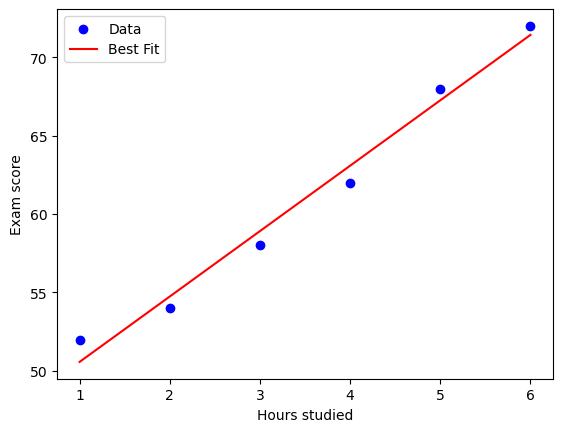

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# Sample data: hours studied vs exam score
X = np.array([1,2,3,4,5,6]).reshape(-1,1) # predictor
y = np.array([52, 54, 58, 62, 68, 72]) # target

# Fit Model
model = LinearRegression()
model.fit(X,y)

# Prediction
y_pred = model.predict(X)

print("Coefficient:", model.coef_)
print("Intercept:", model.intercept_)

#Plot
plt.scatter(X,y, color='blue', label = "Data")
plt.plot(X,y_pred, color ="red", label = "Best Fit")
plt.xlabel("Hours studied")
plt.ylabel("Exam score")
plt.legend()
plt.show()

In [ ]:
# Multiple Linear Regression (several predictors)

In [3]:
import pandas as pd

# Fake dataset: house price based on size and number of bedrooms
data = pd.DataFrame({
    "size": [1000, 1500, 2000, 2500, 3000],
    "bedrooms": [2,3,3,4,4],
    "price": [200000, 250000, 280000,310000, 360000]
})

X = data[["size", "bedrooms"]] # predictors
y = data["price"] # target

model = LinearRegression()
model.fit(X,y)

print("Coefficients:", model.coef_)
print("Intercept:", model.intercept_)

Coefficients: [ 7.60000000e+01 -9.96301962e-12]
Intercept: 127999.99999999997


In [5]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline

pipe = Pipeline([
    ("scaler", StandardScaler()), # normalize predictors
    ("model", LinearRegression())
])

pipe.fit(X, y)

Pipeline(steps=[('scaler', StandardScaler()), ('model', LinearRegression())])

In [6]:
coef_scaled = pipe.named_steps["model"].coef_
intercept_scaled = pipe.named_steps["model"].intercept_

import numpy as np

scaler = pipe.named_steps["scaler"]
linreg = pipe.named_steps["model"]

# Scale parameters
means = scaler.mean_
scales = scaler.scale_

# Rescale coefficients
coef_original = linreg.coef_ / scales
intercept_original = linreg.intercept_ - np.sum((linreg.coef_ * means) / scales)

print("Coefficients (original scale):", coef_original)
print("Intercept (original scale):", intercept_original)

Coefficients (original scale): [ 7.60000000e+01 -1.30446491e-11]
Intercept (original scale): 128000.00000000009


In [7]:
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline

# Dataset: salary depends on education level (categorical)
data = pd.DataFrame({
    "education": ["High School", "Bachelor", "Master", "PhD", "Bachelor"],
    "experience": [1, 3, 5, 7, 2],
    "salary": [30, 50, 70, 90, 55]
})

X = data[["education", "experience"]]
y = data["salary"]

# Preprocess categorical variable
preprocessor = ColumnTransformer(
    transformers=[("edu", OneHotEncoder(drop="first"), ["education"])],
    remainder="passthrough"
)

# Build pipeline
pipe = Pipeline([
    ("preprocess", preprocessor),
    ("model", LinearRegression())
])

pipe.fit(X, y)

print("Coefficients:", pipe.named_steps["model"].coef_)
print("Intercept:", pipe.named_steps["model"].intercept_)


Coefficients: [-30.  30.  60.  -5.]
Intercept: 65.00000000000006


In [8]:
pipe.score(X,y)

1.0

In [9]:
from sklearn.metrics import r2_score
y_pred = pipe.predict(X)
r2_sklearn = r2_score(y, y_pred)
print("sklearn R²:", r2_sklearn)

sklearn R²: 1.0


In [ ]:
# Stepwise vs Lasso regression

In [10]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from sklearn.linear_model import LinearRegression, Lasso

# Synthetic dataset
np.random.seed(42)
X = pd.DataFrame({
    "x1": np.random.randn(100),
    "x2": np.random.randn(100),
    "x3": np.random.randn(100),
    "x4": np.random.randn(100),
    "x5": np.random.randn(100)
})

# True relationship: y = 3*x1 + 2*x3 + noise
y = 3*X["x1"] + 2*X["x3"] + np.random.randn(100)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [11]:
import statsmodels.api as sm

def forward_selection(X, y):
    remaining = list(X.columns)
    selected = []
    current_score, best_new_score = -np.inf, -np.inf
    
    while remaining:
        scores_with_candidates = []
        for candidate in remaining:
            model = sm.OLS(y, sm.add_constant(X[selected + [candidate]])).fit()
            score = model.rsquared_adj
            scores_with_candidates.append((score, candidate))
        scores_with_candidates.sort()
        best_new_score, best_candidate = scores_with_candidates.pop()
        
        if best_new_score > current_score:
            remaining.remove(best_candidate)
            selected.append(best_candidate)
            current_score = best_new_score
        else:
            break
    return selected

selected_features = forward_selection(X_train, y_train)
print("Stepwise selected features:", selected_features)


Stepwise selected features: ['x1', 'x3', 'x5', 'x2']


In [12]:
lasso = Lasso(alpha=0.05)  # alpha = penalty strength
lasso.fit(X_train, y_train)

selected_lasso = [col for col, coef in zip(X_train.columns, lasso.coef_) if coef != 0]
print("Lasso selected features:", selected_lasso)


Lasso selected features: ['x1', 'x2', 'x3', 'x5']


In [14]:
#Stepwise selected features: ['x1', 'x3']
#Lasso selected features: ['x1', 'x3']


In [15]:
# K Means

C:\Users\ekadw\anaconda3\envs\BookTimeSeries\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


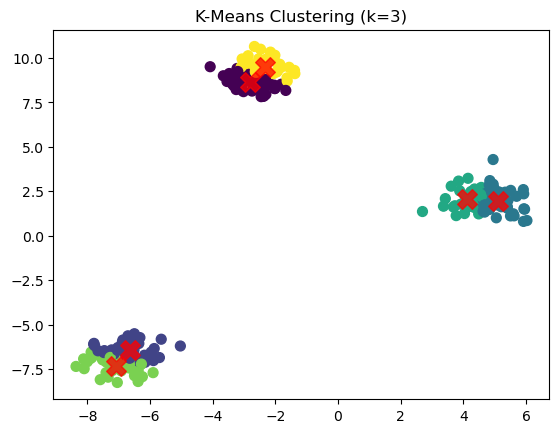

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs
import os
os.environ["OMP_NUM_THREADS"] = "2"

# 1. Generate synthetic dataset (3 clusters)
X, y_true = make_blobs(n_samples=300, centers=3, cluster_std=0.60, random_state=42)

# 2. Fit K-Means
kmeans = KMeans(n_clusters=6, random_state=42, n_init=10)
y_kmeans = kmeans.fit_predict(X)

# 3. Plot results
plt.scatter(X[:, 0], X[:, 1], c=y_kmeans, s=50, cmap='viridis')
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], 
            c='red', s=200, alpha=0.75, marker='X')
plt.title("K-Means Clustering (k=3)")
plt.show()


C:\Users\ekadw\anaconda3\envs\BookTimeSeries\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\ekadw\anaconda3\envs\BookTimeSeries\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\ekadw\anaconda3\envs\BookTimeSeries\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\ekadw\anaconda3\envs\BookTimeSeries\Lib\site-packages\sklearn\clust

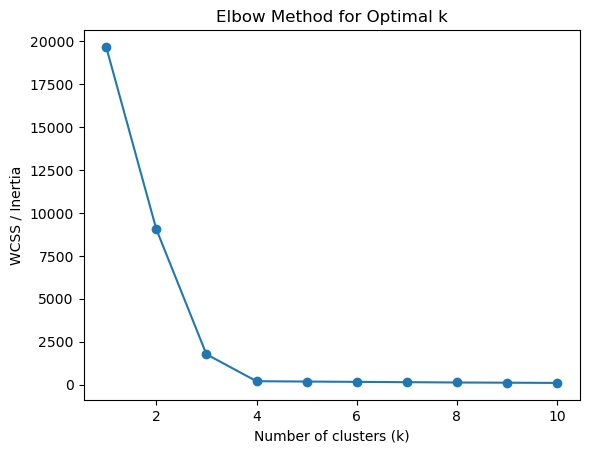

In [20]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs

# Generate synthetic dataset
X, _ = make_blobs(n_samples=300, centers=4, cluster_std=0.60, random_state=42)

# Range of k values to try
k_values = range(1, 11)
wcss = []  # within-cluster sum of squares

# Fit KMeans for each k
for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)  # inertia_ = sum of squared distances to cluster centers

# Plot elbow curve
plt.plot(k_values, wcss, marker='o')
plt.xlabel("Number of clusters (k)")
plt.ylabel("WCSS / Inertia")
plt.title("Elbow Method for Optimal k")
plt.show()


In [ ]:
# Because after k=3 the drop is less step then the k=3 is the optimal clusters

In [24]:
# Survival analysis

In [25]:
import pandas as pd
import numpy as np

# Simulated dataset
np.random.seed(42)
data = pd.DataFrame({
    "age": np.random.randint(30, 80, 10),
    "treatment": np.random.choice([0, 1], size=10),  # 0=control, 1=treated
    "duration": [5, 6, 6, 2, 4, 3, 8, 7, 9, 5],       # time until event or censor
    "event_observed": [1, 0, 1, 1, 0, 1, 0, 1, 1, 1] # 1=event occurred, 0=censored
})

data


,age,treatment,duration,event_observed
0,68,0,5,1
1,58,1,6,0
2,44,0,6,1
3,72,1,2,1
4,37,1,4,0
5,50,1,3,1
6,68,0,8,0
7,48,1,7,1
8,52,0,9,1
9,40,1,5,1


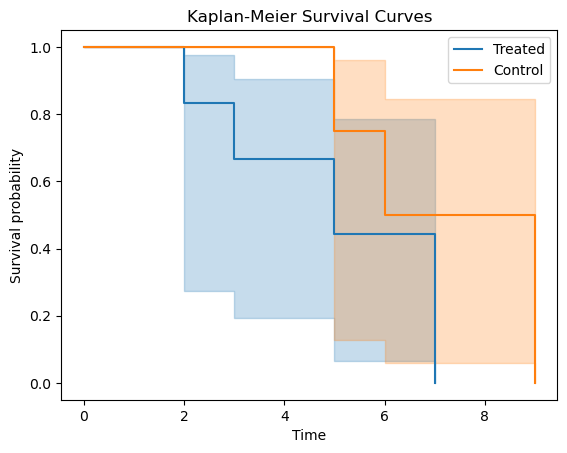

In [26]:
from lifelines import KaplanMeierFitter
import matplotlib.pyplot as plt

kmf = KaplanMeierFitter()

# Fit and plot for treated group
kmf.fit(durations=data[data['treatment']==1]['duration'],
        event_observed=data[data['treatment']==1]['event_observed'],
        label='Treated')
ax = kmf.plot_survival_function()

# Fit and plot for control group
kmf.fit(durations=data[data['treatment']==0]['duration'],
        event_observed=data[data['treatment']==0]['event_observed'],
        label='Control')
kmf.plot_survival_function(ax=ax)

plt.title("Kaplan-Meier Survival Curves")
plt.xlabel("Time")
plt.ylabel("Survival probability")
plt.show()


In [27]:
from lifelines import CoxPHFitter

cph = CoxPHFitter()
cph.fit(data, duration_col='duration', event_col='event_observed')
cph.print_summary()


<lifelines.CoxPHFitter: fitted with 10 total observations, 3 right-censored observations>
             duration col = 'duration'
                event col = 'event_observed'
      baseline estimation = breslow
   number of observations = 10
number of events observed = 7
   partial log-likelihood = -10.30
         time fit was run = 2025-09-11 02:02:23 UTC

---
           coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                  
age        0.02      1.02      0.05           -0.07            0.11                0.93                1.12
treatment  1.06      2.90      0.98           -0.85            2.98                0.43               19.61

           cmp to    z    p  -log2(p)
covariate                            
age          0.00 0.41 0.68      0.55
treatment    0.00 1.09 0.28      1.86
---
Concordance = 0.71
Partial AIC = 24.60
log-likelihood ratio test = 1.29 on 2 df
-log2(p) of ll-ratio test = 0.93

In [ ]:
#Coefficients > 0 → higher hazard (worse survival)

#Coefficients < 0 → lower hazard (better survival)

In [ ]:
# Risk adjustment

In [28]:
import pandas as pd
import numpy as np

# Simulate data
np.random.seed(42)
data = pd.DataFrame({
    "age": np.random.randint(30, 80, 20),
    "treatment": np.random.choice([0, 1], size=20),  # 0=control, 1=treated
    "duration": np.random.randint(1, 15, 20),        # time until event or censor
    "event_observed": np.random.choice([0, 1], size=20) # 1=event occurred
})

data.head()


,age,treatment,duration,event_observed
0,68,1,12,1
1,58,1,14,1
2,44,1,14,1
3,72,1,14,0
4,37,1,3,1


In [29]:
from lifelines import CoxPHFitter

# Cox model: adjust treatment effect for age
cph = CoxPHFitter()
cph.fit(data, duration_col='duration', event_col='event_observed')
cph.print_summary()


<lifelines.CoxPHFitter: fitted with 20 total observations, 8 right-censored observations>
             duration col = 'duration'
                event col = 'event_observed'
      baseline estimation = breslow
   number of observations = 20
number of events observed = 12
   partial log-likelihood = -24.55
         time fit was run = 2025-09-11 02:08:39 UTC

---
           coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                  
age       -0.03      0.97      0.03           -0.08            0.02                0.92                1.02
treatment -0.12      0.89      0.68           -1.46            1.22                0.23                3.39

           cmp to     z    p  -log2(p)
covariate                             
age          0.00 -1.22 0.22      2.17
treatment    0.00 -0.18 0.86      0.22
---
Concordance = 0.67
Partial AIC = 53.11
log-likelihood ratio test = 1.73 on 2 df
-log2(p) of ll-ratio test = 1.24

AttributeError: Line2D.set() got an unexpected keyword argument 'reference_values'

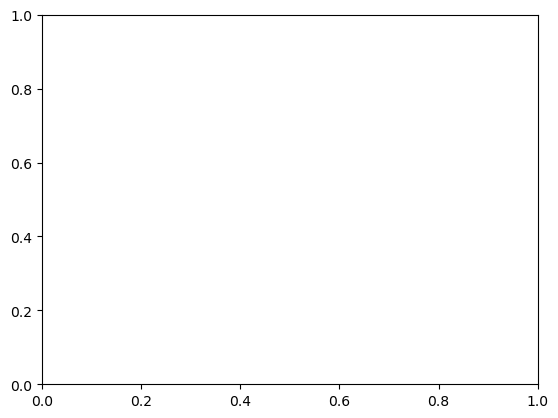

In [31]:
from lifelines import CoxPHFitter
import matplotlib.pyplot as plt

# Assume `data` is already defined
cph = CoxPHFitter()
cph.fit(data, duration_col='duration', event_col='event_observed')

# Plot partial effects
# Adjusting for age at median value
median_age = data['age'].median()

ax = cph.plot_partial_effects_on_outcome(
    covariates='treatment',      # variable to compare
    values=[0, 1],               # control vs treated
    reference_values={'age': median_age},
    cmap='coolwarm'
)

plt.title("Risk-Adjusted Survival Curves (Adjusted for Age)")
plt.xlabel("Time")
plt.ylabel("Survival Probability")
plt.show()


In [ ]:
# GLM

In [32]:
import pandas as pd
import numpy as np
import statsmodels.api as sm

# Simulate dataset
np.random.seed(42)
n = 100
age = np.random.randint(20, 70, n)
bmi = np.random.normal(25, 4, n)
diabetes = (0.05*age + 0.1*bmi + np.random.randn(n)) > 7  # binary outcome

data = pd.DataFrame({"age": age, "bmi": bmi, "diabetes": diabetes.astype(int)})

# Add constant for intercept
X = sm.add_constant(data[["age", "bmi"]])
y = data["diabetes"]

# Fit logistic regression (GLM with binomial family)
model = sm.GLM(y, X, family=sm.families.Binomial())
result = model.fit()

print(result.summary())


                 Generalized Linear Model Regression Results                  
Dep. Variable:               diabetes   No. Observations:                  100
Model:                            GLM   Df Residuals:                       97
Model Family:                Binomial   Df Model:                            2
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -12.282
Date:                Wed, 10 Sep 2025   Deviance:                       24.563
Time:                        23:16:18   Pearson chi2:                     79.1
No. Iterations:                     7   Pseudo R-squ. (CS):            0.02357
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -9.5900      4.746     -2.021      0.0

In [33]:
# Simulate count data
np.random.seed(123)
n = 100
age = np.random.randint(20, 80, n)
smoker = np.random.choice([0, 1], size=n)  # 0=non-smoker, 1=smoker
visits = np.random.poisson(lam=0.05*age + 2*smoker)

data2 = pd.DataFrame({"age": age, "smoker": smoker, "visits": visits})

# Add constant
X2 = sm.add_constant(data2[["age", "smoker"]])
y2 = data2["visits"]

# Fit Poisson regression
model2 = sm.GLM(y2, X2, family=sm.families.Poisson())
result2 = model2.fit()

print(result2.summary())


                 Generalized Linear Model Regression Results                  
Dep. Variable:                 visits   No. Observations:                  100
Model:                            GLM   Df Residuals:                       97
Model Family:                 Poisson   Df Model:                            2
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -195.04
Date:                Wed, 10 Sep 2025   Deviance:                       108.36
Time:                        23:17:29   Pearson chi2:                     93.9
No. Iterations:                     4   Pseudo R-squ. (CS):             0.3956
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0274      0.211     -0.130      0.8

In [34]:
# Time series

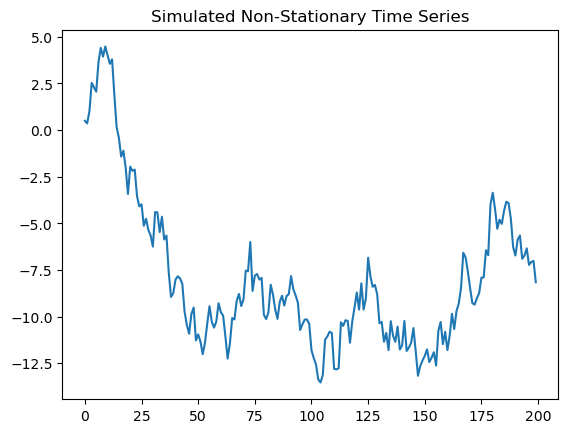

ADF Statistic: -2.3072851790645257
p-value: 0.1696291207894371


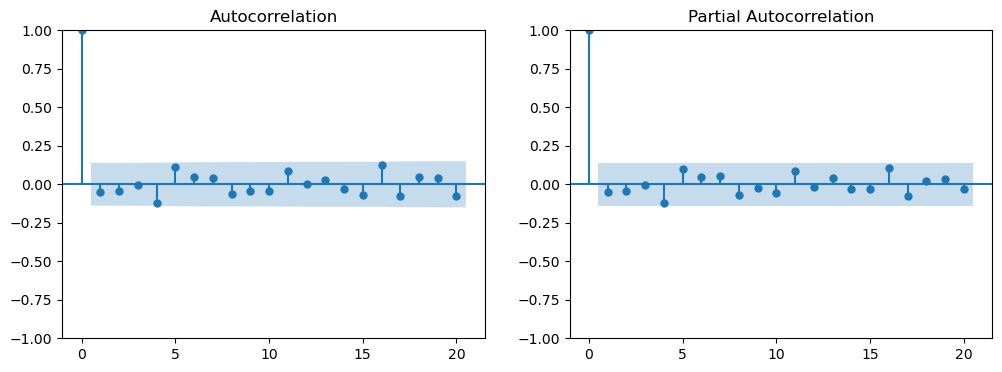

In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller

# Simulate ARIMA-like data (random walk + noise)
np.random.seed(42)
n = 200
y = np.cumsum(np.random.normal(size=n))  # non-stationary

plt.plot(y)
plt.title("Simulated Non-Stationary Time Series")
plt.show()

# 1. Check stationarity with Augmented Dickey-Fuller test
adf_result = adfuller(y)
print("ADF Statistic:", adf_result[0])
print("p-value:", adf_result[1])

# If p-value > 0.05 → non-stationary → apply differencing
y_diff = np.diff(y)

# 2. Plot ACF and PACF for differenced series
fig, axes = plt.subplots(1, 2, figsize=(12,4))
plot_acf(y_diff, lags=20, ax=axes[0])
plot_pacf(y_diff, lags=20, ax=axes[1])
plt.show()


In [37]:
import pmdarima as pm

# Fit auto_arima
model = pm.auto_arima(
    y,
    start_p=0, start_q=0,
    max_p=3, max_q=3,
    d=None,               # auto-diff
    seasonal=False,       # non-seasonal example
    trace=True,
    error_action='ignore',
    suppress_warnings=True,
    stepwise=True
)

print(model.summary())


Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=539.949, Time=0.07 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=541.422, Time=0.03 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=541.373, Time=0.03 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=538.383, Time=0.01 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=542.901, Time=0.06 sec

Best model:  ARIMA(0,1,0)(0,0,0)[0]          
Total fit time: 0.188 seconds
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  200
Model:               SARIMAX(0, 1, 0)   Log Likelihood                -268.191
Date:                Wed, 10 Sep 2025   AIC                            538.383
Time:                        23:24:11   BIC                            541.676
Sample:                             0   HQIC                           539.716
                                - 200                                         
Co

C:\Users\ekadw\anaconda3\envs\BookTimeSeries\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\ekadw\anaconda3\envs\BookTimeSeries\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\ekadw\anaconda3\envs\BookTimeSeries\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\ekadw\anaconda3\envs\BookTimeSeries\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\ekadw\anaconda3\envs\BookTimeSeries\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finit

Best ARIMA order: (0, 1, 0)
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  200
Model:                 ARIMA(0, 1, 0)   Log Likelihood                -268.191
Date:                Wed, 10 Sep 2025   AIC                            538.383
Time:                        23:27:00   BIC                            541.676
Sample:                             0   HQIC                           539.716
                                - 200                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
sigma2         0.8672      0.088      9.896      0.000       0.695       1.039
Ljung-Box (L1) (Q):                   0.53   Jarque-Bera (JB):                 0.65
Prob(Q):           

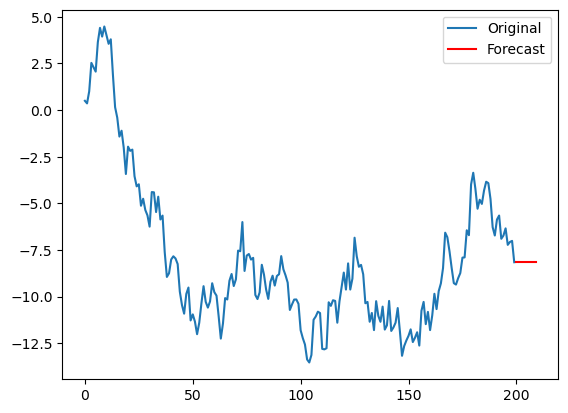

In [38]:
from statsmodels.tsa.arima.model import ARIMA

best_order = model.order  # from auto_arima
print("Best ARIMA order:", best_order)

final_model = ARIMA(y, order=best_order).fit()
print(final_model.summary())

# Forecast next 10 steps
forecast = final_model.forecast(steps=10)
print("Forecast:", forecast)

plt.plot(y, label="Original")
plt.plot(range(len(y), len(y)+10), forecast, label="Forecast", color="red")
plt.legend()
plt.show()
